# OS Model 

Overall goal of this notebook

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load in the fitz datasets from the Skin Tone Analysis

In [3]:
fitz_1=pd.read_csv("../Skin Tone Analysis/fitz_1.csv")
fitz_2=pd.read_csv("../Skin Tone Analysis/fitz_2.csv")
fitz_3=pd.read_csv("../Skin Tone Analysis/fitz_3.csv")
fitz_4=pd.read_csv("../Skin Tone Analysis/fitz_4.csv")
fitz_5=pd.read_csv("../Skin Tone Analysis/fitz_5.csv")
fitz_6=pd.read_csv("../Skin Tone Analysis/fitz_6.csv")

Filter outliers for `oxy_sat_comparison` for each fitz and create a distribution for output errors to input into skin tone component in final equation.

Create a range of bias values for a range OS values for each fitz value. Where the OS ranges will be based on the healhy/ diseased status:
- Healthy: 95 > x >= 97
- Hyperventilation: > 97
- Hypoxemia: 87 > x >= 95
- Severe: 59 > x >= 87

This will be the raw data that should be included in the microcontroller.

In [4]:
def group_by_saturation(df):
    """Group the DataFrame by so2_mean (true OS not measured by pulse ox) into defined bins.
    """
    # Group so2_mean into bins
    bins = [0, 59, 87, 94, 97, 100]
    # Define labels for the bins
    labels = ['Dead', 'Severe', 'Hypoxemia', 'Healthy', 'Hyperventilation']
    # Create a new column 'so2_group' based on the bins
    df['so2_group'] = pd.cut(df['so2_mean'], bins=bins, labels=labels)
    return df

In [5]:
fitz_1

,encounter_id,sample_number,saturation,so2_filled,saturation_mean,so2_mean,oxy_sat_comparison,fitzpatrick
0,023153e2349d0b1fd2677b51e963194f83fe919e52c12b...,2.0,"[96.0, 96.0, 96.0, 97.0, 96.0, 97.0, 96.0, 96....","[96.6, 96.4]",96.3,96.50,-0.20,1.0
1,023153e2349d0b1fd2677b51e963194f83fe919e52c12b...,3.0,"[97.0, 96.0, 97.0, 97.0, 96.0, 97.0, 97.0, 97....","[96.4, 96.2]",96.7,96.30,0.40,1.0
2,023153e2349d0b1fd2677b51e963194f83fe919e52c12b...,4.0,"[96.0, 96.0, 97.0, 97.0, 96.0, 97.0, 97.0, 97....","[96.6, 96.8]",96.6,96.70,-0.10,1.0
3,023153e2349d0b1fd2677b51e963194f83fe919e52c12b...,5.0,"[96.0, 96.0, 97.0, 97.0, 96.0, 97.0, 97.0, 96....","[96.5, 96.8]",96.5,96.65,-0.15,1.0
4,023153e2349d0b1fd2677b51e963194f83fe919e52c12b...,6.0,"[88.0, 88.0, 88.0, 89.0, 87.0, 87.0, 84.0, 86....","[87.4, 87.6]",86.6,87.50,-0.90,1.0
...,...,...,...,...,...,...,...,...
2093,f85b6055e849faa315493022ebeee01adbfa23faa99adc...,21.0,"[83.0, 81.0]",[83.6],82.0,83.60,-1.60,1.0
2094,f85b6055e849faa315493022ebeee01adbfa23faa99adc...,23.0,"[71.0, 68.0]",[70.8],69.5,70.80,-1.30,1.0
2095,f85b6055e849faa315493022ebeee01adbfa23faa99adc...,24.0,"[72.0, 68.0]",[70.8],70.0,70.80,-0.80,1.0
2096,f85b6055e849faa315493022ebeee01adbfa23faa99adc...,25.0,"[70.0, 67.0]",[69.6],68.5,69.60,-1.10,1.0


In [6]:
group_by_saturation(fitz_1)
group_by_saturation(fitz_2)
group_by_saturation(fitz_3)
group_by_saturation(fitz_4)
group_by_saturation(fitz_5)
group_by_saturation(fitz_6)

,encounter_id,sample_number,saturation,so2_filled,saturation_mean,so2_mean,oxy_sat_comparison,fitzpatrick,so2_group
0,02c37e54017643ceb7b0a9cdc05348c6737a1aa6434d0e...,2.0,"[97.9, 97.0, 98.0, 94.0]","[94.8, 94.6]",96.725,94.700000,2.025000,6.0,Healthy
1,02c37e54017643ceb7b0a9cdc05348c6737a1aa6434d0e...,3.0,"[97.4, 96.0, 97.0, 98.0, 94.0]","[94.4, 94.1]",96.480,94.250000,2.230000,6.0,Healthy
2,02c37e54017643ceb7b0a9cdc05348c6737a1aa6434d0e...,4.0,"[97.4, 96.0, 96.0, 98.0, 94.0]","[94.2, 93.8, 94.5]",96.280,94.166667,2.113333,6.0,Healthy
3,02c37e54017643ceb7b0a9cdc05348c6737a1aa6434d0e...,5.0,"[97.0, 96.0, 94.0, 97.0, 94.0]","[94.0, 93.9]",95.600,93.950000,1.650000,6.0,Hypoxemia
4,02c37e54017643ceb7b0a9cdc05348c6737a1aa6434d0e...,6.0,"[86.0, 93.0, 89.0, 82.0]","[84.0, 83.5]",87.500,83.750000,3.750000,6.0,Severe
...,...,...,...,...,...,...,...,...,...
3645,ff340351558c84be44dc642830770aeed2f91215f86f5f...,21.0,"[85.0, 84.0, 81.0, 84.0]","[79.2, 79.4]",83.500,79.300000,4.200000,6.0,Severe
3646,ff340351558c84be44dc642830770aeed2f91215f86f5f...,22.0,"[82.0, 81.0, 80.0, 80.0]","[76.8, 76.4]",80.750,76.600000,4.150000,6.0,Severe
3647,ff340351558c84be44dc642830770aeed2f91215f86f5f...,23.0,"[81.0, 80.0, 79.0]","[76.3, 76.4]",80.000,76.350000,3.650000,6.0,Severe
3648,ff340351558c84be44dc642830770aeed2f91215f86f5f...,24.0,"[81.0, 77.0, 81.0, 79.0]","[75.7, 76.2]",79.500,75.950000,3.550000,6.0,Severe


Exclude outliers from each oxy_sat_comparison values using IQR truncation. 

In [7]:
def truncate_by_group_iqr(df, so2_group, bias, k=1.5):
    """Truncate outliers in the DataFrame based on the IQR method for each group defined by so2_group.
    """
    def truncate(group):

    # Calculate the first and third quartiles and the IQR for the oxy_sat_comparison column
        q1 = group[bias].quantile(0.25)
        q3 = group[bias].quantile(0.75)
        iqr = q3 - q1
    # Define the lower and upper bounds for outliers
        lower = q1 - k * iqr
        upper = q3 + k * iqr
    # Return the group with outliers removed
        return group[(group[bias] >= lower) &
                     (group[bias] <= upper)]
    
    # Apply the truncate function to each group defined by so2_group and conc the results
    return (
        df.groupby(so2_group, group_keys=False)
          .apply(truncate)
          .reset_index(drop=True)
    )


Truncate by group for each fitz df (1-6)

In [8]:
fitz_1_trunx=truncate_by_group_iqr(fitz_1, 'so2_group', 'oxy_sat_comparison')
fitz_2_trunx=truncate_by_group_iqr(fitz_2, 'so2_group', 'oxy_sat_comparison')
fitz_3_trunx=truncate_by_group_iqr(fitz_3, 'so2_group', 'oxy_sat_comparison')
fitz_4_trunx=truncate_by_group_iqr(fitz_4, 'so2_group', 'oxy_sat_comparison')
fitz_5_trunx=truncate_by_group_iqr(fitz_5, 'so2_group', 'oxy_sat_comparison')
fitz_6_trunx=truncate_by_group_iqr(fitz_6, 'so2_group', 'oxy_sat_comparison')

In [9]:
fitz_1_trunx.to_csv("fitz_1_model.csv", index=False)
fitz_2_trunx.to_csv("fitz_2_model.csv", index=False)
fitz_3_trunx.to_csv("fitz_3_model.csv", index=False)
fitz_4_trunx.to_csv("fitz_4_model.csv", index=False)
fitz_5_trunx.to_csv("fitz_5_model.csv", index=False)
fitz_6_trunx.to_csv("fitz_6_model.csv", index=False)

Check: Ensure counts and means values are similar but with smaller range of mins and maxs between og df and trunx df.

In [10]:
fitz_1.groupby('so2_group')['oxy_sat_comparison'].describe()


,count,mean,std,min,25%,50%,75%,max
so2_group,,,,,,,,
Dead,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Severe,1187.0,0.392928,1.992906,-11.200000,-0.623214,0.450000,1.505000,9.966667
Hypoxemia,483.0,0.960126,1.362259,-2.050000,-0.091667,0.800000,1.841667,5.950000
Healthy,383.0,0.686325,1.176015,-2.271429,-0.141667,0.678571,1.493750,3.550000
Hyperventilation,45.0,0.348170,1.020603,-1.400000,-0.500000,0.300000,1.050000,2.400000


In [11]:
fitz_1_trunx.groupby('so2_group')['oxy_sat_comparison'].describe()

,count,mean,std,min,25%,50%,75%,max
so2_group,,,,,,,,
Dead,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Severe,1141.0,0.495531,1.608840,-3.800000,-0.522222,0.488889,1.50000,4.600000
Hypoxemia,477.0,0.906457,1.282312,-2.050000,-0.100000,0.800000,1.80000,4.666667
Healthy,383.0,0.686325,1.176015,-2.271429,-0.141667,0.678571,1.49375,3.550000
Hyperventilation,45.0,0.348170,1.020603,-1.400000,-0.500000,0.300000,1.05000,2.400000


Check distribution through scatterplot

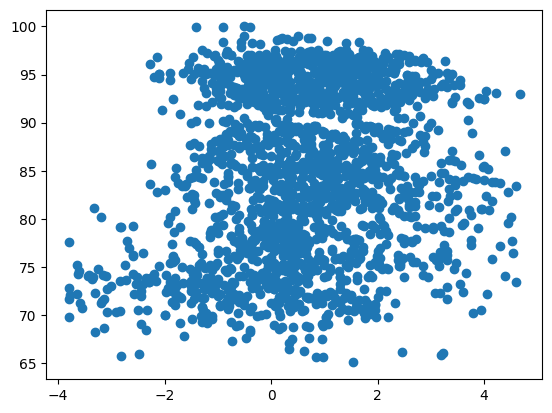

In [13]:
plt.scatter(fitz_1_trunx['oxy_sat_comparison'], (fitz_1_trunx['so2_mean']))

Gather distribution value for temp ranges based on an input temp value or low perfusion (15-18 degrees C).
Temp ranges gathered is on for colder temperatures (18-20 degrees C) which could be seen as low perfusion.

Pulse ox eading IQR: 97.5 - 100
Culse pulse ox reading IQR: 87.1 - 92.7